# Regressão Linear com PyTorch - Dataset Salary Data

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [1]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [7]:
!pwd

/content


In [8]:
#!/bin/bash
!curl -L -o /content/salary-data.zip https://www.kaggle.com/api/v1/datasets/download/abhishek14398/salary-dataset-simple-linear-regression

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   457  100   457    0     0   1563      0 --:--:-- --:--:-- --:--:--  1563


In [9]:
!unzip /content/salary-data.zip

Archive:  /content/salary-data.zip
  inflating: Salary_dataset.csv      


In [10]:
# Load the dataset
df = pd.read_csv('Salary_dataset.csv')

X = df[['YearsExperience']].values
y = df[['Salary']].values

In [13]:
y

array([[ 39344.],
       [ 46206.],
       [ 37732.],
       [ 43526.],
       [ 39892.],
       [ 56643.],
       [ 60151.],
       [ 54446.],
       [ 64446.],
       [ 57190.],
       [ 63219.],
       [ 55795.],
       [ 56958.],
       [ 57082.],
       [ 61112.],
       [ 67939.],
       [ 66030.],
       [ 83089.],
       [ 81364.],
       [ 93941.],
       [ 91739.],
       [ 98274.],
       [101303.],
       [113813.],
       [109432.],
       [105583.],
       [116970.],
       [112636.],
       [122392.],
       [121873.]])

### Normalização dos dados

In [14]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [18]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([21, 1])
y_train_tensor shape: torch.Size([21, 1])
X_val_tensor shape: torch.Size([9, 1])
y_val_tensor shape: torch.Size([9, 1])


## Criação do modelo da rede

In [42]:
model = torch.nn.Linear(1, 1)

### Verificando a inicialização dos parâmetros

In [26]:
model.weight.data

tensor([[-0.8834]])

### Testando o predict da rede

In [27]:
model(torch.ones(5,1))

tensor([[-0.4821],
        [-0.4821],
        [-0.4821],
        [-0.4821],
        [-0.4821]], grad_fn=<AddmmBackward0>)

In [34]:
model(X_train_tensor[:3])

tensor([[1.0764],
        [0.9435],
        [0.5932]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [43]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.3)
num_epochs = 120

### Laço de treinamento

In [44]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [45]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [46]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # verbose
    if (epoch + 1) % 2 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[2/120], Train Loss: 0.152620, Val Loss: 0.065730
Epoch[4/120], Train Loss: 0.041270, Val Loss: 0.053959
Epoch[6/120], Train Loss: 0.039858, Val Loss: 0.052487
Epoch[8/120], Train Loss: 0.039813, Val Loss: 0.052132
Epoch[10/120], Train Loss: 0.039811, Val Loss: 0.052041
Epoch[12/120], Train Loss: 0.039810, Val Loss: 0.052017
Epoch[14/120], Train Loss: 0.039810, Val Loss: 0.052011
Epoch[16/120], Train Loss: 0.039810, Val Loss: 0.052010
Epoch[18/120], Train Loss: 0.039810, Val Loss: 0.052009
Epoch[20/120], Train Loss: 0.039810, Val Loss: 0.052009
Epoch[22/120], Train Loss: 0.039810, Val Loss: 0.052009
Epoch[24/120], Train Loss: 0.039810, Val Loss: 0.052009
Epoch[26/120], Train Loss: 0.039810, Val Loss: 0.052009
Epoch[28/120], Train Loss: 0.039810, Val Loss: 0.052009
Epoch[30/120], Train Loss: 0.039810, Val Loss: 0.052009
Epoch[32/120], Train Loss: 0.039810, Val Loss: 0.052009
Epoch[34/120], Train Loss: 0.039810, Val Loss: 0.052009
Epoch[36/120], Train Loss: 0.039810, Val Loss: 0.052

## Avaliação

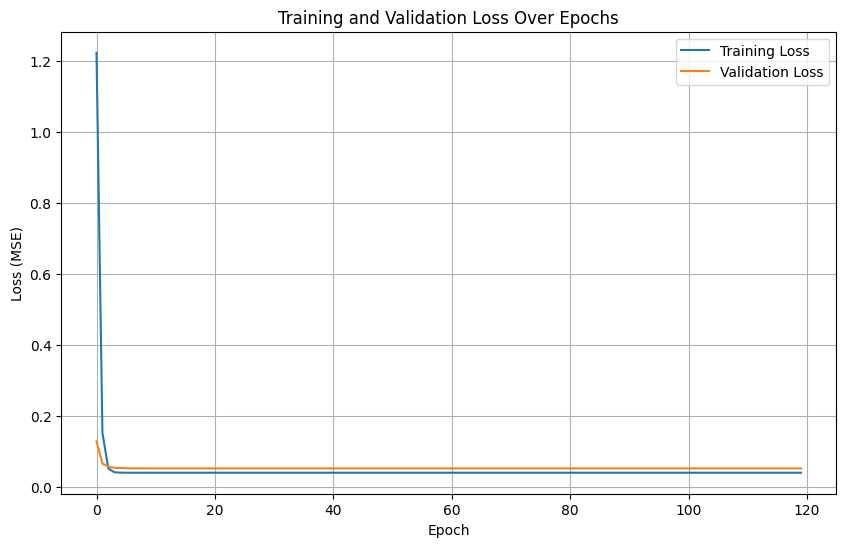

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()